In [2]:
import os

# Garante que a execução comece dentro da pasta 'tarefa4'
import pathlib
if pathlib.Path().resolve().name != 'tarefa4':
    os.chdir(os.path.join(os.getcwd(), 'deeplearning', 'tarefa4'))

%pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121

if "sam2" not in os.listdir():
    !git clone https://github.com/facebookresearch/sam2.git
    %cd sam2
    %pip install -e .
else:
    %cd sam2

%cd checkpoints

if "sam2.1_hiera_small.pt" not in os.listdir():
    !wget -O sam2.1_hiera_small.pt "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt"

%cd ..

%cd sam2

Note: you may need to restart the kernel to use updated packages.
/home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2
/home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2/checkpoints
/home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2
/home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2/sam2


In [3]:
import torch
import torchvision

print("CUDA is available:", torch.cuda.is_available())
print("GPU memory (in GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024 / 1024 / 1024, 2))

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

# Notebook de exemplo do facebook usa
if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

CUDA is available: True
GPU memory (in GB): 3.81
Using device: cuda


In [5]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)

In [4]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("polomarco/chest-ct-segmentation")
print("Path to dataset files:", path)

# Estrutura do dataset: images/, masks/, pretrained_model/, train.csv
images_dir = os.path.join(path, "images", "images")
masks_dir = os.path.join(path, "masks", "masks")
train_csv_path = os.path.join(path, "train.csv")

df = pd.read_csv(train_csv_path)

df.head()


/home/gustavo/codigos/MachineLearning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/gustavo/.cache/kagglehub/datasets/polomarco/chest-ct-segmentation/versions/3


,ImageId,MaskId
0,ID00007637202177411956430_0.jpg,ID00007637202177411956430_mask_0.jpg
1,ID00007637202177411956430_1.jpg,ID00007637202177411956430_mask_1.jpg
2,ID00007637202177411956430_2.jpg,ID00007637202177411956430_mask_2.jpg
3,ID00007637202177411956430_3.jpg,ID00007637202177411956430_mask_3.jpg
4,ID00007637202177411956430_4.jpg,ID00007637202177411956430_mask_4.jpg


In [6]:
image_files = df['ImageId'].tolist()
image_filename = df['ImageId'][2]
image_sample_path = os.path.join(images_dir, image_filename)

mask_files = df['MaskId'].tolist()
mask_filename = df['MaskId'][2]
mask_sample_path = os.path.join(masks_dir, mask_filename)

In [7]:
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt

train_df, test_df = train_test_split(df, train_size=0.1, random_state=42)

# Apenas para testar as funções
train_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in train_df.iterrows()
]

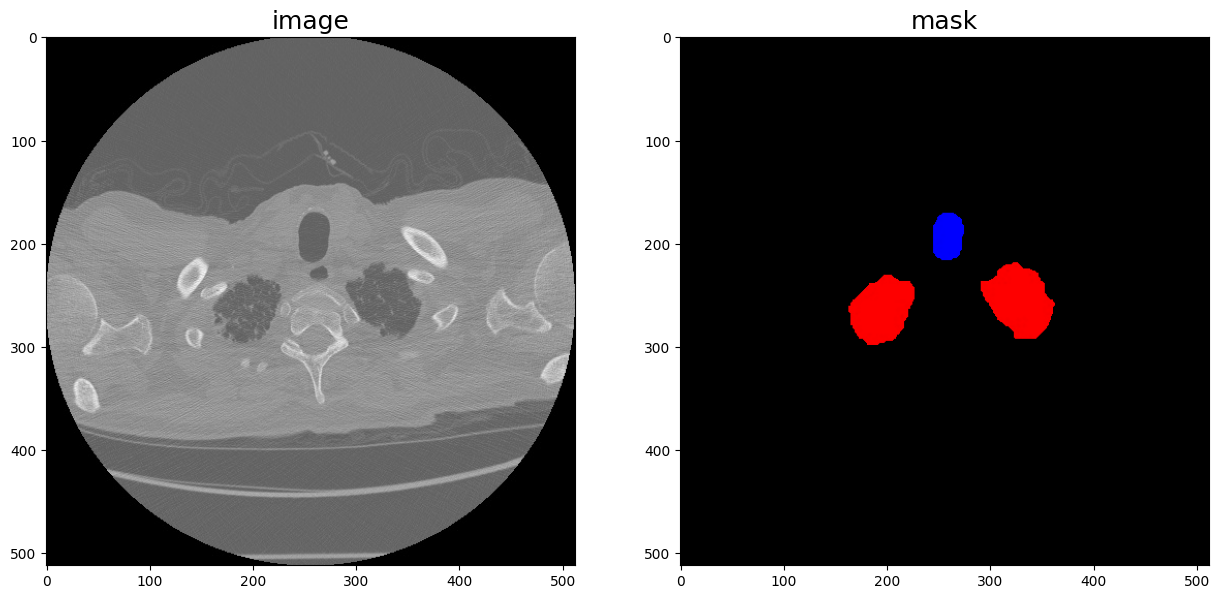

In [8]:
def get_data(img_path, mask_path):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path)
    mask[mask < 240] = 0  # remove artifacts

    return img, mask

one_slice_img, one_slice_mask = get_data(image_sample_path, mask_sample_path)

data_to_plot = [one_slice_img, one_slice_mask]
labels = ['image', 'mask']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

for i, ax in enumerate(axes):
    ax.imshow(data_to_plot[i])
    ax.set_title(labels[i], fontdict={"fontsize": 18})

In [33]:
def visualize_batch(img, masks):
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    # Primeira linha: imagem original, máscara rgb, overlay
    axs[0, 0].imshow(img)
    axs[0, 0].set_title('Imagem')
    axs[0, 0].axis('off')

    mask_rgb = np.stack(masks, axis=-1)
    axs[0, 1].imshow(mask_rgb)
    axs[0, 1].set_title('Máscara (RGB)')
    axs[0, 1].axis('off')

    # Overlay: imagem original + máscara sem perder o canal RGB
    # máscara deve estar entre 0-1, shape igual a img[:,:,:3]
    mask_overlay = (mask_rgb > 0).astype(np.float32)
    mask_color = mask_overlay * np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])  # r,g,b por classe
    mask_color = mask_overlay * np.array([1, 0, 0])[None, None, :]
    mask_color[..., 0] = mask_overlay[..., 0]  # Red para classe 0
    mask_color[..., 1] = mask_overlay[..., 1]  # Green para classe 1
    mask_color[..., 2] = mask_overlay[..., 2]  # Blue para classe 2
    # Se img for uint8, precisamos normalizar para float [0-1]
    img_float = img / 255.0 if img.dtype == np.uint8 else img.copy()
    # O overlay mistura a imagem original com a máscara de cor
    alpha = 0.3
    overlay = img_float * (1 - alpha) + mask_color * alpha
    overlay = np.clip(overlay, 0, 1)
    axs[0, 2].imshow(overlay)
    axs[0, 2].set_title('Overlay')
    axs[0, 2].axis('off')

    # Segunda linha: máscaras binárias de cada classe
    names = ['Lung', 'Heart', 'Trachea']
    for i in range(3):
        axs[1, i].imshow(masks[i], cmap='gray')
        axs[1, i].set_title(names[i])
        axs[1, i].axis('off')

    plt.tight_layout()
    plt.show()

def visualize_batch_with_points(img, masks, points, labels):
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    axs[0, 0].imshow(img)
    axs[0, 0].set_title('Imagem')
    axs[0, 0].axis('off')

    mask_rgb = np.stack(masks, axis=-1)
    axs[0, 1].imshow(mask_rgb)
    axs[0, 1].set_title('Máscara (RGB)')
    axs[0, 1].axis('off')

    # Overlay corrigido
    mask_overlay = (mask_rgb > 0).astype(np.float32)
    mask_color = mask_overlay * np.array([1, 0, 0])[None, None, :]
    mask_color[..., 0] = mask_overlay[..., 0]
    mask_color[..., 1] = mask_overlay[..., 1]
    mask_color[..., 2] = mask_overlay[..., 2]
    img_float = img / 255.0 if img.dtype == np.uint8 else img.copy()
    alpha = 0.3
    overlay = img_float * (1 - alpha) + mask_color * alpha
    overlay = np.clip(overlay, 0, 1)
    axs[0, 2].imshow(overlay)
    axs[0, 2].set_title('Overlay')
    axs[0, 2].axis('off')

    names = ['Lung', 'Heart', 'Trachea']
    cores = ['red', 'green', 'blue']
    for i in range(3):
        axs[1, i].imshow(masks[i], cmap='gray')
        axs[1, i].set_title(names[i])
        axs[1, i].axis('off')
        for pt, lbl in zip(points, labels):
            if lbl == i:
                axs[1, i].scatter(pt[0], pt[1], c=cores[i], s=70, marker='o', edgecolors='white', linewidths=1.5)
    plt.tight_layout()
    plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import cv2
import numpy as np

def get_points_from_mask(mask, min_area_ratio=0.05, erode_iter=2):
    """
    Args:
        erode_iter: Quantas vezes 'lixar' o objeto. Aumente se ainda estiverem colados.
    """
    points = []

    # 1. Garante binário
    binary_mask = (mask > 0).astype(np.uint8) * 255

    if binary_mask.sum() == 0:
        return points

    #Erosão
    kernel = np.ones((3,3), np.uint8)

    # Criamos uma máscara separada apenas para calcular os centros
    # Assim não perdemos tamanho real se precisássemos dele, mas para o ponto central é ótimo
    detection_mask = cv2.erode(binary_mask, kernel, iterations=erode_iter)

    # Se a erosão sumiu com tudo (objeto muito pequeno), volta pro original como fallback
    if detection_mask.sum() == 0:
        detection_mask = binary_mask

    # 2. Encontra componentes (agora na máscara erodida/separada)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(detection_mask, connectivity=8)

    if num_labels <= 1:
        return points

    # 3. Define threshold
    areas = stats[1:, cv2.CC_STAT_AREA]
    max_area = np.max(areas)
    min_area_threshold = max(max_area * min_area_ratio, 100)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        if area < min_area_threshold:
            continue

        # Lógica inteligente de centroide vs ponto interno
        cx, cy = int(centroids[i][0]), int(centroids[i][1])

        # Verifica na máscara erodida se o centroide é válido
        if labels[cy, cx] == i:
            points.append([cx, cy])
        else:
            # Distance Transform para achar o miolo
            component_mask = (labels == i).astype(np.uint8)
            dist_transform = cv2.distanceTransform(component_mask, cv2.DIST_L2, 5)
            _, _, _, max_loc = cv2.minMaxLoc(dist_transform)
            points.append([max_loc[0], max_loc[1]])

    return points

def read_batch(data, visualize = ""):
    """Carrega e processa dados. Retorna imagem, máscaras por canal, pontos e labels."""
    ent = data[np.random.randint(len(data))]
    img, mask = get_data(ent["image"], ent["annotation"])

    # Separa por canais
    masks = [mask[:,:,0], mask[:,:,1], mask[:,:,2]]
    class_names = ['lung', 'heart', 'trachea']

    # Resize imagem e máscaras para largura ou altura máxima de 1024
    r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])  # Scaling factor
    new_shape = (int(img.shape[1] * r), int(img.shape[0] * r))
    img = cv2.resize(img, new_shape)
    masks = [cv2.resize(m, new_shape, interpolation=cv2.INTER_NEAREST) for m in masks]

    points = []
    labels = []
    for i, m in enumerate(masks):
        pts = get_points_from_mask(m)
        points += pts
        labels += [i]*len(pts)


    points = np.array(points)   # shape (Total, 2)
    labels = np.array(labels)   # shape (Total,)

    # Visualização
    if visualize == "image":
        visualize_batch(img, masks)
    elif visualize == "points":
        visualize_batch_with_points(img, masks, points, labels)

    masks_formatted = [np.expand_dims(m, axis=-1) for m in masks]

    return img, masks_formatted, points, labels, mask

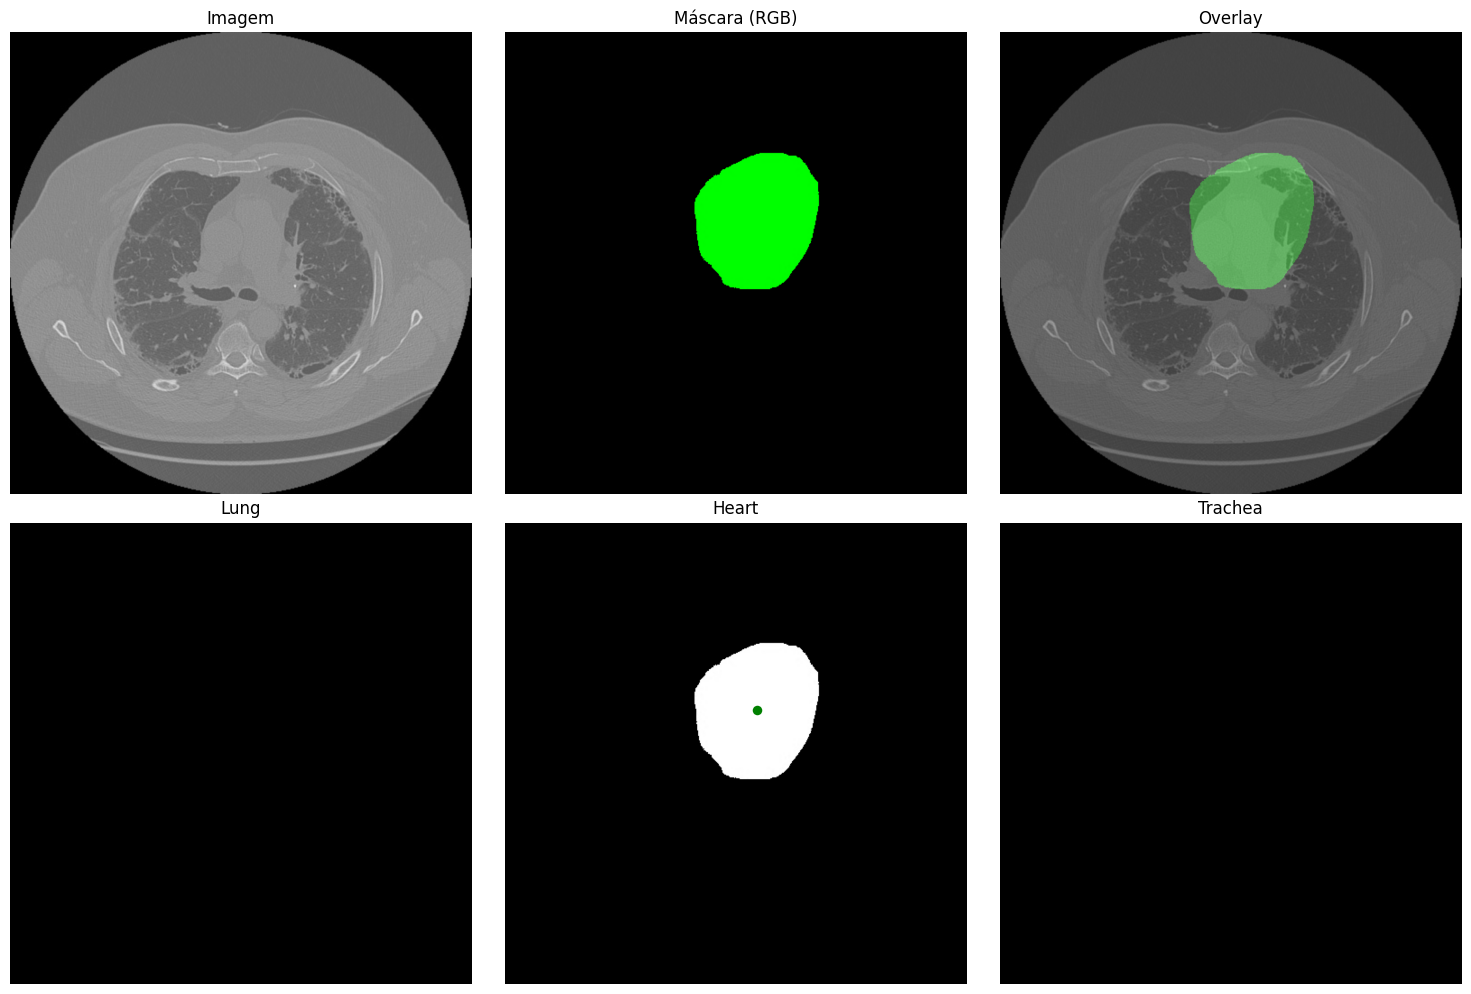

In [141]:
# Carrega e visualiza dados
img, masks, points, labels, rgb_mask = read_batch(train_data, visualize = "points")

In [142]:
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    # Define the number of columns and rows for the subplots
    n = len(masks)
    if n > 3:
        ncols = 3
    else:
        ncols = n
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 6*nrows))

    # axs is 2D array-like even if nrows=1 or ncols=1
    axs = np.array(axs).reshape(-1)
    for i, (mask, score) in enumerate(zip(masks, scores)):
        ax = axs[i]
        ax.imshow(image)
        show_mask(mask, ax, borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, ax)
        if box_coords is not None:
            show_box(box_coords, ax)
        if len(scores) > 1:
            ax.set_title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        ax.axis('off')

    plt.show()

# Predict


In [143]:
with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    predictor.set_image(img)

    # Para cada classe fazemos a predição separada
    all_masks = []
    all_scores = []
    all_logits = []

    for class_id in range(3):
        # Pega apenas os pontos da classe atual
        class_points = points[labels == class_id]

        if len(class_points) > 0:
            # Label do SAM
            class_labels = np.ones(len(class_points), dtype=np.int32)

            masks_cls, scores_cls, logits_cls = predictor.predict(
                point_coords=class_points,
                point_labels=class_labels,
                multimask_output=True,
            )

            # Pega a melhor máscara
            all_masks.append(masks_cls[np.argmax(scores_cls)])
            all_scores.append(scores_cls[np.argmax(scores_cls)])
            all_logits.append(logits_cls[np.argmax(scores_cls)])
        else:
            # Se não há pontos para esta classe, cria máscara vazia
            h, w = img.shape[:2]
            all_masks.append(np.zeros((h, w), dtype=bool))
            all_scores.append(0.0)
            all_logits.append(None)

    masks = np.array(all_masks)
    scores = np.array(all_scores)
    logits = all_logits

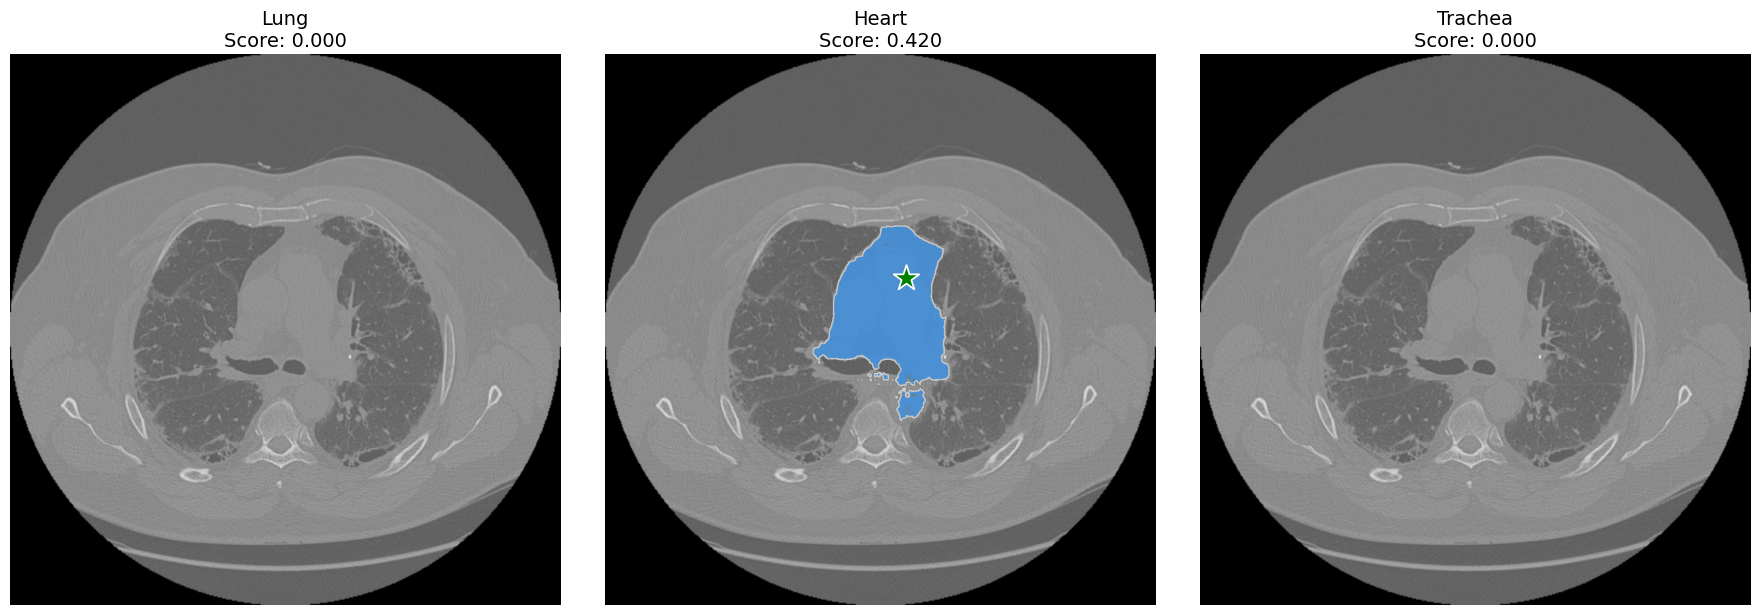

In [144]:
# Mostra as máscaras de cada classe com seus respectivos pontos
class_names = ['Lung', 'Heart', 'Trachea']
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i in range(3):
    ax = axs[i]
    ax.imshow(img)
    show_mask(masks[i], ax, borders=True)

    # Mostra os pontos da classe i
    class_points = points[labels == i]
    if len(class_points) > 0:
        # Todos os pontos são foreground (label=1)
        class_labels = np.ones(len(class_points), dtype=np.int32)
        show_points(class_points, class_labels, ax)

    ax.set_title(f"{class_names[i]}\nScore: {scores[i]:.3f}", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

Carregando 20 imagens e fazendo predições...
Carregadas 20 imagens!


Output()

In [ ]:
Faça a predição para 20 imagens do treino usando o sam base e mostre isso:

# Mostra as máscaras de cada classe com seus respectivos pontos
class_names = ['Lung', 'Heart', 'Trachea']
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i in range(3):
    ax = axs[i]
    ax.imshow(img)
    show_mask(masks[i], ax, borders=True)

    # Mostra os pontos da classe i
    class_points = points[labels == i]
    if len(class_points) > 0:
        # Todos os pontos são foreground (label=1)
        class_labels = np.ones(len(class_points), dtype=np.int32)
        show_points(class_points, class_labels, ax)

    ax.set_title(f"{class_names[i]}\nScore: {scores[i]:.3f}", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

e isso:

# Carrega e visualiza dados
img, masks, points, labels, rgb_mask = read_batch(train_data, visualize = "points")

SyntaxError: invalid syntax (319924782.py, line 1)

# Fine-tuning - V1

Vamos treinar o modelo SAM2 com diferentes funções de perda, comparando:
- Cross Entropy Loss
- Dice Loss
- Dice + BCE Loss

Todos os modelos serão treinados por 3000 steps, apenas no mask decoder.


In [16]:
# Separar dataset em treino (80%), validação (5%) e teste (15%)
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.05/0.85, random_state=42)

# Prepara listas de dados
train_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in train_df.iterrows()
]

val_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in val_df.iterrows()
]

test_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in test_df.iterrows()
]

print(f"Treino: {len(train_data)}, Validação: {len(val_data)}, Teste: {len(test_data)}")

Treino: 13365, Validação: 836, Teste: 2507


In [17]:
# Funções de Loss
def cross_entropy_loss(gt_mask, prd_mask):
    """Binary Cross Entropy Loss"""
    return (-gt_mask * torch.log(prd_mask + 1e-6) - (1 - gt_mask) * torch.log((1 - prd_mask) + 1e-6)).mean()

def dice_loss(gt_mask, prd_mask, smooth=1.):
    """Dice Loss"""
    gt_flat = gt_mask.contiguous().view(-1)
    prd_flat = prd_mask.contiguous().view(-1)
    intersection = (gt_flat * prd_flat).sum()
    dice = (2. * intersection + smooth) / (gt_flat.sum() + prd_flat.sum() + smooth)
    return 1 - dice

def dice_bce_loss(gt_mask, prd_mask, smooth=1., bce_weight=0.5):
    """Combinação de Dice Loss e BCE Loss"""
    dice = dice_loss(gt_mask, prd_mask, smooth)
    bce = cross_entropy_loss(gt_mask, prd_mask)
    return bce_weight * bce + (1 - bce_weight) * dice


In [18]:
# Função para visualizar predição em uma imagem da validação
def visualize_prediction_on_validation(img, all_masks, all_scores, points, labels):
    """
    Faz uma predição em uma imagem aleatória da validação e visualiza o resultado.

    Args:
        predictor: SAM2ImagePredictor instance
        val_data: Lista de dados de validação
    """
    # Visualiza
    class_names = ['Lung', 'Heart', 'Trachea']
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    for i in range(3):
        ax = axs[i]
        ax.imshow(img)
        show_mask(all_masks[i], ax, borders=True)

        # Mostra os pontos da classe i
        class_points = points[labels == i]
        if len(class_points) > 0:
            class_labels = np.ones(len(class_points), dtype=np.int32)
            show_points(class_points, class_labels, ax)

        ax.set_title(f"{class_names[i]}\nScore: {all_scores[i]:.3f}", fontsize=14)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [19]:
# Função de avaliação na validação
def evaluate_on_validation(predictor, val_data, verbose=True, max_samples=None, visualize=False):
    """
    Avalia o predictor no conjunto de validação calculando o IoU total e por classe.

    Args:
        predictor: SAM2ImagePredictor instance
        val_data: Lista de dados de validação
        verbose: Se True, imprime progresso

    Returns:
        dict: {'overall_mean_iou': float, 'class_mean_ious': list, 'class_infos': dict, 'total_images_evaluated': int}
    """
    predictor.model.eval()

    all_iou_scores = []
    num_images = 0

    # Para IoU por classe
    num_classes = 3  # Se precisar, ajeite para o número real de classes
    all_iou_scores_per_class = [[] for _ in range(num_classes)]

    if max_samples is None:
        max_samples = len(val_data)

    # Amostra algumas imagens para avaliação rápida (para não demorar muito)
    eval_data = val_data[:min(max_samples, len(val_data))]

    print_idx = np.random.randint(0, len(eval_data))

    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        for idx, data_entry in enumerate(eval_data):
            # Carrega dados diretamente do data_entry
            img, mask = get_data(data_entry["image"], data_entry["annotation"])

            if img is None or mask is None:
                continue

            # Separa por canais
            masks_list = [mask[:,:,0], mask[:,:,1], mask[:,:,2]]

            # Resize para processamento
            r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])
            new_shape = (int(img.shape[1] * r), int(img.shape[0] * r))
            img_resized = cv2.resize(img, new_shape)
            masks_resized = [cv2.resize(m, new_shape, interpolation=cv2.INTER_NEAREST) for m in masks_list]

            # Extrai pontos para cada classe
            points = []
            labels = []
            for i, m in enumerate(masks_resized):
                pts = get_points_from_mask(m)
                points += pts
                labels += [i] * len(pts)

            points = np.array(points)
            labels = np.array(labels)

            if len(points) == 0:
                continue

            # Define a imagem
            predictor.set_image(img_resized)

            image_iou_scores = []

            # Listas para visualização (uma entrada para cada classe)
            all_masks = []
            all_scores = []

            # Para cada classe
            for class_id in range(num_classes):
                class_points = points[labels == class_id]

                if len(class_points) == 0:
                    # Se não há pontos para esta classe, adiciona máscara vazia e score 0
                    h, w = img_resized.shape[:2]
                    all_masks.append(np.zeros((h, w), dtype=bool))
                    all_scores.append(0.0)
                    continue

                # Labels para o SAM
                class_labels = np.ones(len(class_points), dtype=np.int32)

                # Predição
                masks_pred, scores_pred, _ = predictor.predict(
                    point_coords=class_points,
                    point_labels=class_labels,
                    multimask_output=True,
                )

                # Pega a melhor máscara
                best_mask_idx = np.argmax(scores_pred)
                pred_mask = masks_pred[best_mask_idx]

                # Adiciona à lista para visualização
                all_masks.append(pred_mask)
                all_scores.append(scores_pred[best_mask_idx])

                # Ground truth
                gt_mask = masks_resized[class_id]

                # Calcula IoU
                intersection = np.logical_and(gt_mask > 240, pred_mask).sum()
                union = np.logical_or(gt_mask > 240, pred_mask).sum()

                if union > 0:
                    iou = intersection / union
                    image_iou_scores.append(iou)
                    all_iou_scores_per_class[class_id].append(iou)
                else:
                    # Conta como iou zero para a classe, se quiser
                    pass

            # Visualiza APÓS processar todas as classes
            if print_idx == idx and visualize == True:
                visualize_prediction_on_validation(img_resized, all_masks, all_scores, points, labels)

            # IoU médio da imagem
            if len(image_iou_scores) > 0:
                avg_image_iou = np.mean(image_iou_scores)
                all_iou_scores.append(avg_image_iou)
                num_images += 1

            if verbose and (idx + 1) % 20 == 0 and len(image_iou_scores) > 0:
                print(f"  Avaliando imagem {idx + 1}/{len(eval_data)}: IoU médio = {avg_image_iou:.4f}")

    # Calcula IoU médio total
    if len(all_iou_scores) > 0:
        mean_iou = np.mean(all_iou_scores)
    else:
        mean_iou = 0.0

    # IoU médios e infos por classe
    class_infos = {}
    class_mean_ious = []
    for class_id in range(num_classes):
        ious = all_iou_scores_per_class[class_id]
        if len(ious) > 0:
            mean_c = float(np.mean(ious))
            n_c = len(ious)
        else:
            mean_c,  n_c = 0.0, 0.0
        class_mean_ious.append(mean_c)
        class_infos[class_id] = {
            "mean_iou": mean_c,
            "num_samples": n_c
        }

    class_names = ["Lung", "Heart", "Trachea"]
    class_infos = {class_names[i]: v for i, v in class_infos.items()}

    predictor.model.train()  # Volta para modo de treino

    return {
        "overall_mean_iou": float(mean_iou),
        "class_mean_ious": class_mean_ious,
        "class_infos": class_infos,
        "total_images_evaluated": num_images
    }


In [ ]:
# Função de treinamento organizada
def train_model(predictor, optimizer, scaler, train_data, val_data, seg_loss_fn, model_name,
                num_steps=3000, checkpoint_interval=500, val_interval=500):
    """
    Treina o modelo SAM2.

    Args:
        predictor: SAM2ImagePredictor instance já configurado (modo train/eval definido)
        optimizer: Optimizer já configurado
        scaler: GradScaler já configurado
        train_data: Lista de dados de treino
        val_data: Lista de dados de validação
        seg_loss_fn: Função de loss (cross_entropy_loss, dice_loss, dice_bce_loss)
        model_name: Nome do modelo para salvar checkpoints
        num_steps: Número de steps de treinamento
        checkpoint_interval: Intervalo para salvar checkpoint
        val_interval: Intervalo para avaliar na validação

    Returns:
        predictor: Predictor treinado
    """
    # Scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.2)
    accumulation_steps = 4

    # Parâmetros para clip de gradientes
    trainable_params = [p for p in predictor.model.parameters() if p.requires_grad]

    # Histórico de métricas
    train_iou_history = []
    val_iou_history = []

    print(f"\n{'='*60}")
    print(f"Iniciando treinamento: {model_name}")
    print(f"Loss function: {seg_loss_fn.__name__}")
    print(f"Steps: {num_steps}")
    print(f"{'='*60}\n")

    for step in range(1, num_steps + 1):
        with torch.amp.autocast("cuda"):
            # Carrega dados de treino
            image, masks_list, points, labels, rgb_mask = read_batch(train_data)

            if image is None or masks_list is None or len(points) == 0:
                continue

            # Define a imagem uma vez (compartilhada entre todas as classes)
            predictor.set_image(image)

            # Acumula losses de todas as classes
            total_loss = 0.0
            total_iou = []
            num_valid_classes = 0

            # Para cada classe (0, 1, 2), faz uma passada separada
            for class_id in range(3):
                # Pega apenas os pontos da classe atual
                class_points = points[labels == class_id]

                # Se não há pontos para esta classe, pula
                if len(class_points) == 0:
                    continue

                # Todos os pontos têm label=1 (foreground) para o SAM
                class_labels = np.ones(len(class_points), dtype=np.int32)

                # Prepara os prompts
                mask_input, unnorm_coords, sam_labels, unnorm_box = predictor._prep_prompts(
                    class_points, class_labels, box=None, mask_logits=None, normalize_coords=True
                )

                if unnorm_coords is None or sam_labels is None or unnorm_coords.shape[0] == 0 or sam_labels.shape[0] == 0:
                    continue

                # Encoder de prompts
                sparse_embeddings, dense_embeddings = predictor.model.sam_prompt_encoder(
                    points=(unnorm_coords, sam_labels), boxes=None, masks=None,
                )

                # Decoder de máscaras
                batched_mode = unnorm_coords.shape[0] > 1
                high_res_features = [feat_level[-1].unsqueeze(0) for feat_level in predictor._features["high_res_feats"]]
                low_res_masks, prd_scores, _, _ = predictor.model.sam_mask_decoder(
                    image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
                    image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings=sparse_embeddings,
                    dense_prompt_embeddings=dense_embeddings,
                    multimask_output=True,
                    repeat_image=batched_mode,
                    high_res_features=high_res_features,
                )
                prd_masks = predictor._transforms.postprocess_masks(low_res_masks, predictor._orig_hw[-1])

                # Ground truth: máscara binária da classe atual
                gt_mask = torch.tensor(masks_list[class_id].squeeze().astype(np.float32)).cuda()
                # Normaliza para 0-1 se estiver em escala 0-255
                if gt_mask.max() > 1.0:
                    gt_mask = (gt_mask > 0).float()  # Binariza e converte para 0-1
                else:
                    gt_mask = (gt_mask > 0.5).float()  # Binariza se já estiver normalizada

                # Predição: pega a primeira máscara (melhor score)
                prd_mask = torch.sigmoid(prd_masks[:, 0])

                # Loss de segmentação
                seg_loss = seg_loss_fn(gt_mask, prd_mask)

                # IoU
                inter = (gt_mask * (prd_mask > 0.5)).sum()
                union = gt_mask.sum() + (prd_mask > 0.5).sum() - inter
                iou = inter / (union + 1e-8)
                score_loss = torch.abs(prd_scores[:, 0] - iou).mean()

                # Loss total para esta classe
                class_loss = seg_loss + score_loss * 0.05

                # Acumula a loss
                total_loss = total_loss + class_loss
                total_iou.append(iou.cpu().detach().item())
                num_valid_classes += 1

            # Se não há classes válidas, pula este step
            if num_valid_classes == 0:
                continue

            # Normaliza a loss pelo número de classes e accumulation_steps
            total_loss = total_loss / (num_valid_classes * accumulation_steps)

            # Backward pass
            scaler.scale(total_loss).backward()

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)

            # Update weights a cada accumulation_steps
            if step % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                predictor.model.zero_grad()
                scheduler.step()

            # Calcula IoU médio de treino
            if len(total_iou) > 0:
                mean_iou = np.mean(total_iou)
                train_iou_history.append(mean_iou)

            if step % checkpoint_interval == 0:
                # Avalia na validação
                val_results = evaluate_on_validation(predictor, val_data, max_samples=200, verbose=False, visualize=True)
                val_iou = val_results['overall_mean_iou']
                val_iou_history.append((step, val_iou))
                print(f"Step {step}: Train IoU = {mean_iou:.4f}, Val IoU = {val_iou:.4f}")

                # Salva checkpoint
                os.makedirs("custom_checkpoints", exist_ok=True)
                checkpoint_name = f"custom_checkpoints/{model_name}_step_{step}.torch"
                torch.save(predictor.model.state_dict(), checkpoint_name)
                print(f"Checkpoint salvo: {checkpoint_name}")
            elif step % val_interval == 0:
                # Avalia na validação sem imagem
                val_results = evaluate_on_validation(predictor, val_data, max_samples=100, verbose=False)
                val_iou = val_results['overall_mean_iou']
                val_iou_history.append((step, val_iou))
                print(f"Step {step}: Train IoU = {mean_iou:.4f}, Val IoU = {val_iou:.4f}")

    # Avaliação final na validação
    final_val_results = evaluate_on_validation(predictor, val_data, verbose=True)
    final_val_iou = final_val_results['overall_mean_iou']
    print(f"\n{'='*60}")
    print(f"Treinamento concluído: {model_name}")
    print(f"IoU final na validação: {final_val_iou:.4f}")
    print(f"{'='*60}\n")

    return predictor


## Modelo 1: Cross Entropy Loss


In [ ]:
# Recarrega modelo base
sam2_checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)
predictor_ce = SAM2ImagePredictor(sam2_model)

# Configura treinamento apenas no mask decoder
predictor_ce.model.sam_mask_decoder.train(True)
predictor_ce.model.sam_prompt_encoder.train(True)
predictor_ce.model.image_encoder.train(False)

# Configura optimizer apenas para mask decoder
optimizer_ce = torch.optim.AdamW(params=predictor_ce.model.parameters(), lr=0.0001, weight_decay=1e-4)

print("Numero de parametros: ", sum(p.numel() for p in predictor_ce.model.parameters()))
print("Numero de parametros treinaveis: ", sum(p.numel() for p in predictor_ce.model.parameters() if p.requires_grad))

# Mixed precision
scaler_ce = torch.amp.GradScaler("cuda")

# Treina modelo com Cross Entropy
predictor_ce = train_model(
    predictor=predictor_ce,
    optimizer=optimizer_ce,
    scaler=scaler_ce,
    train_data=train_data,
    val_data=val_data,
    seg_loss_fn=cross_entropy_loss,
    model_name="model_ce",
    num_steps=3000,
    checkpoint_interval=500,
    val_interval=100,
    debug=True
)


## Modelo 2: Dice Loss



Iniciando treinamento: model_dice
Loss function: dice_loss
Steps: 3000

Step 100: Train IoU = 0.7915, Val IoU = 0.6124
Step 200: Train IoU = 0.4260, Val IoU = 0.6129
Step 400: Train IoU = 0.6258, Val IoU = 0.6124


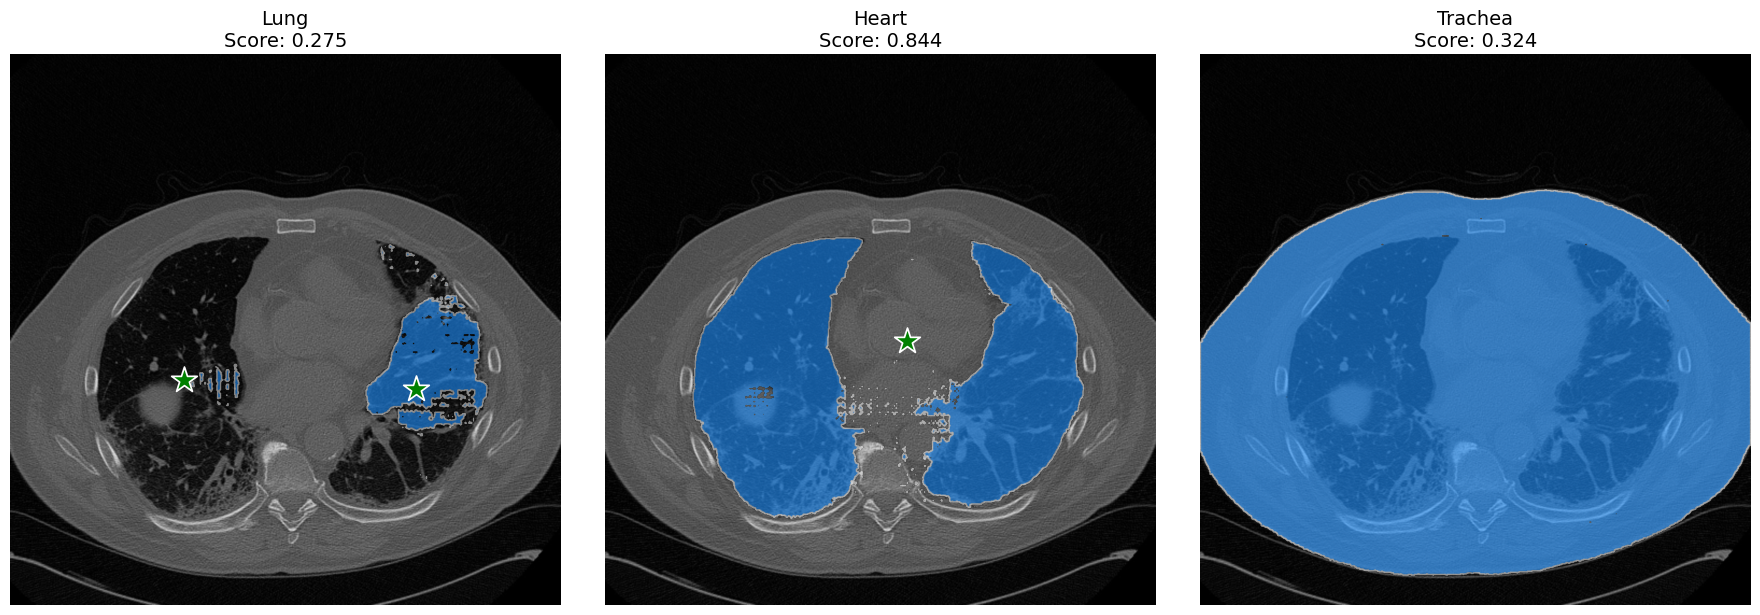

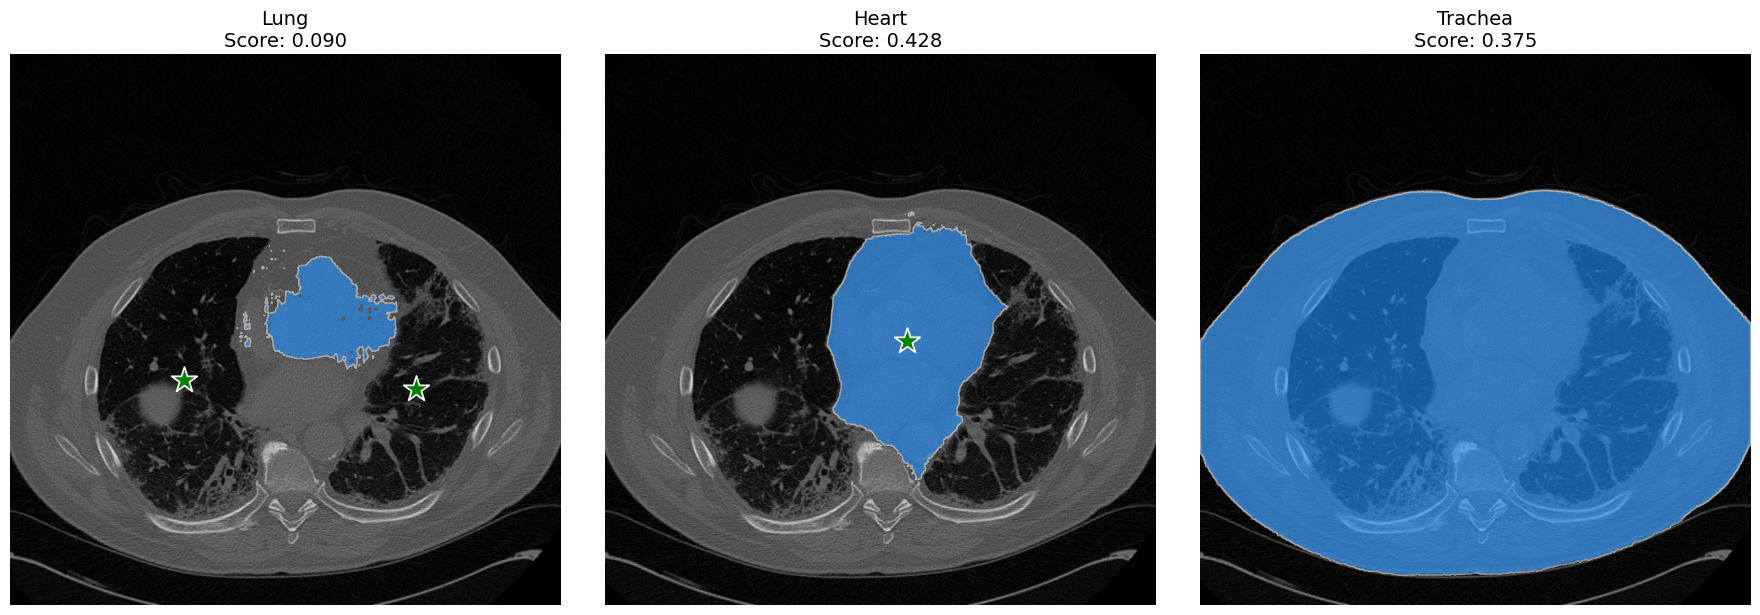

Step 500: Train IoU = 0.0297, Val IoU = 0.5875
Checkpoint salvo: custom_checkpoints/model_dice_step_500.torch
Step 700: Train IoU = 0.1243, Val IoU = 0.6234
Step 900: Train IoU = 0.6467, Val IoU = 0.6252


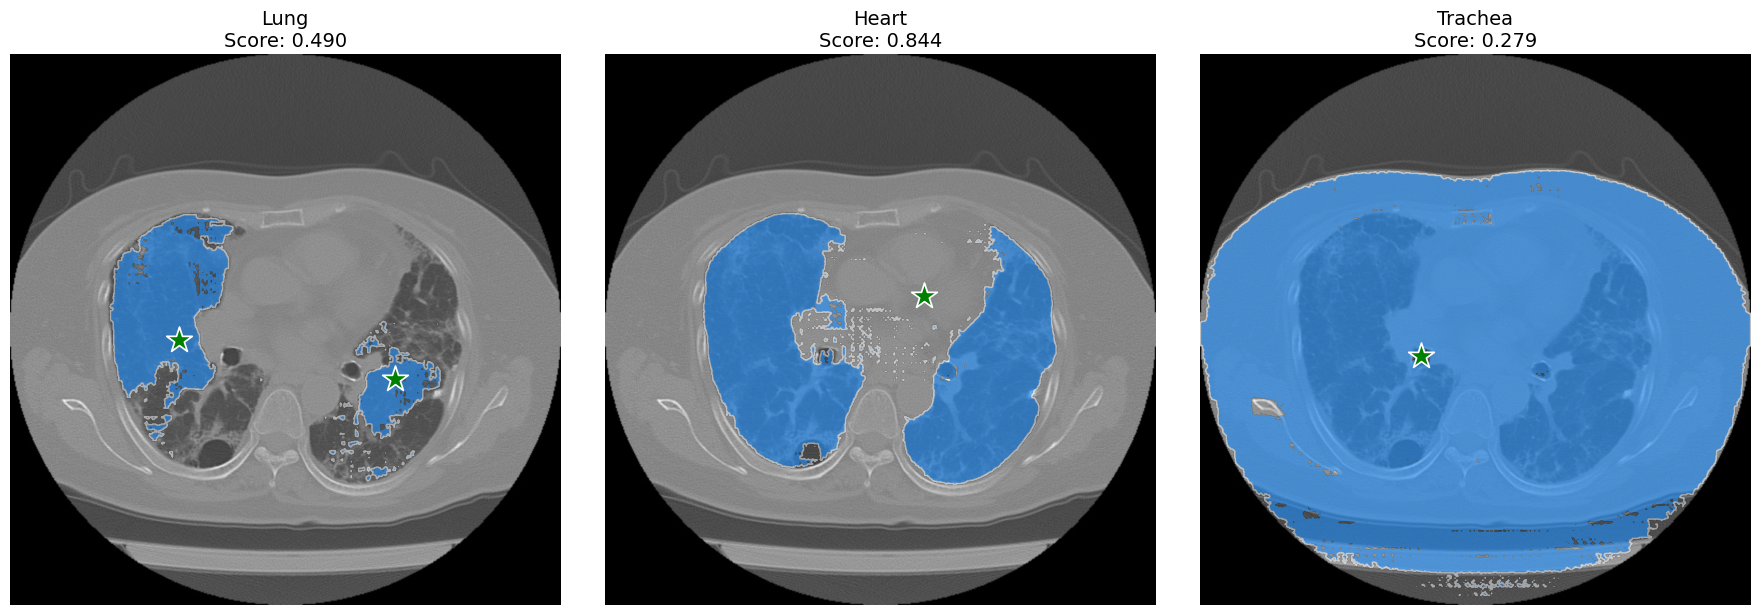

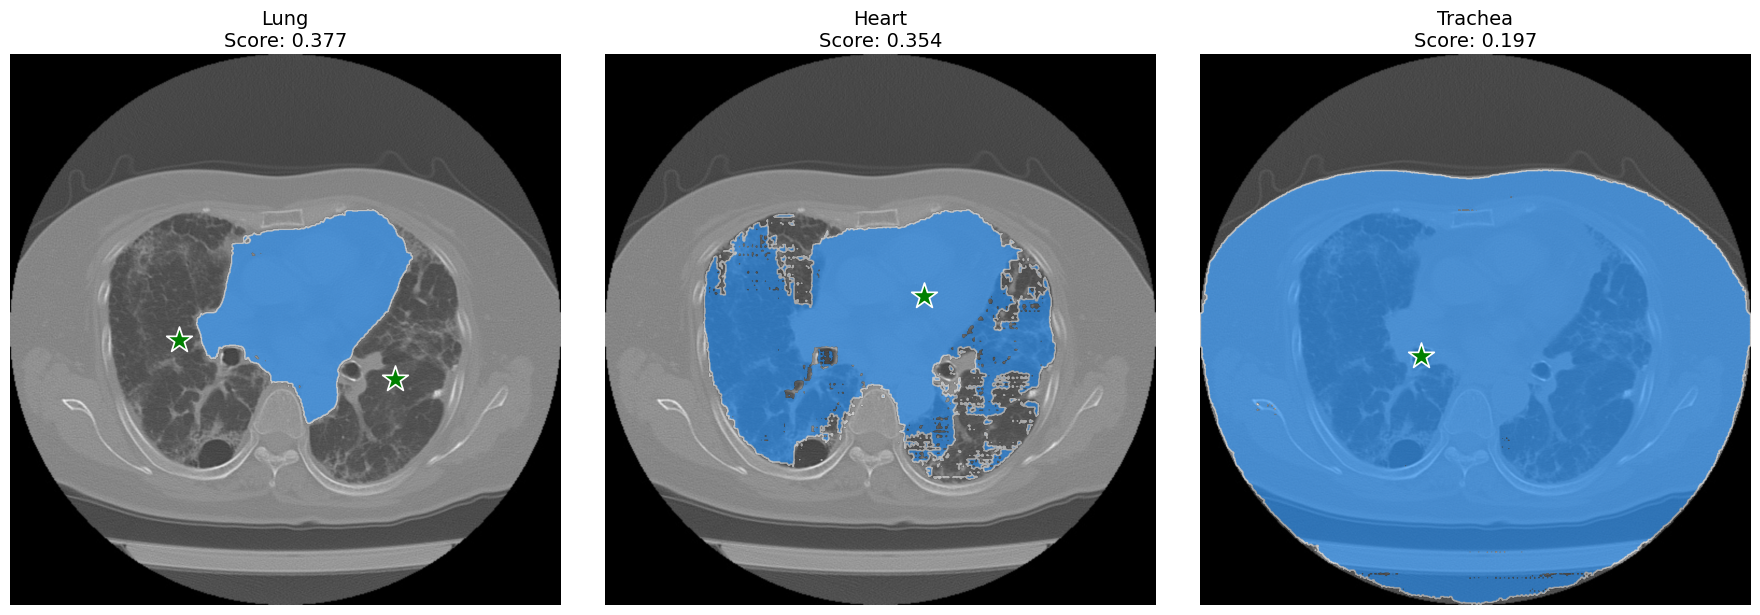

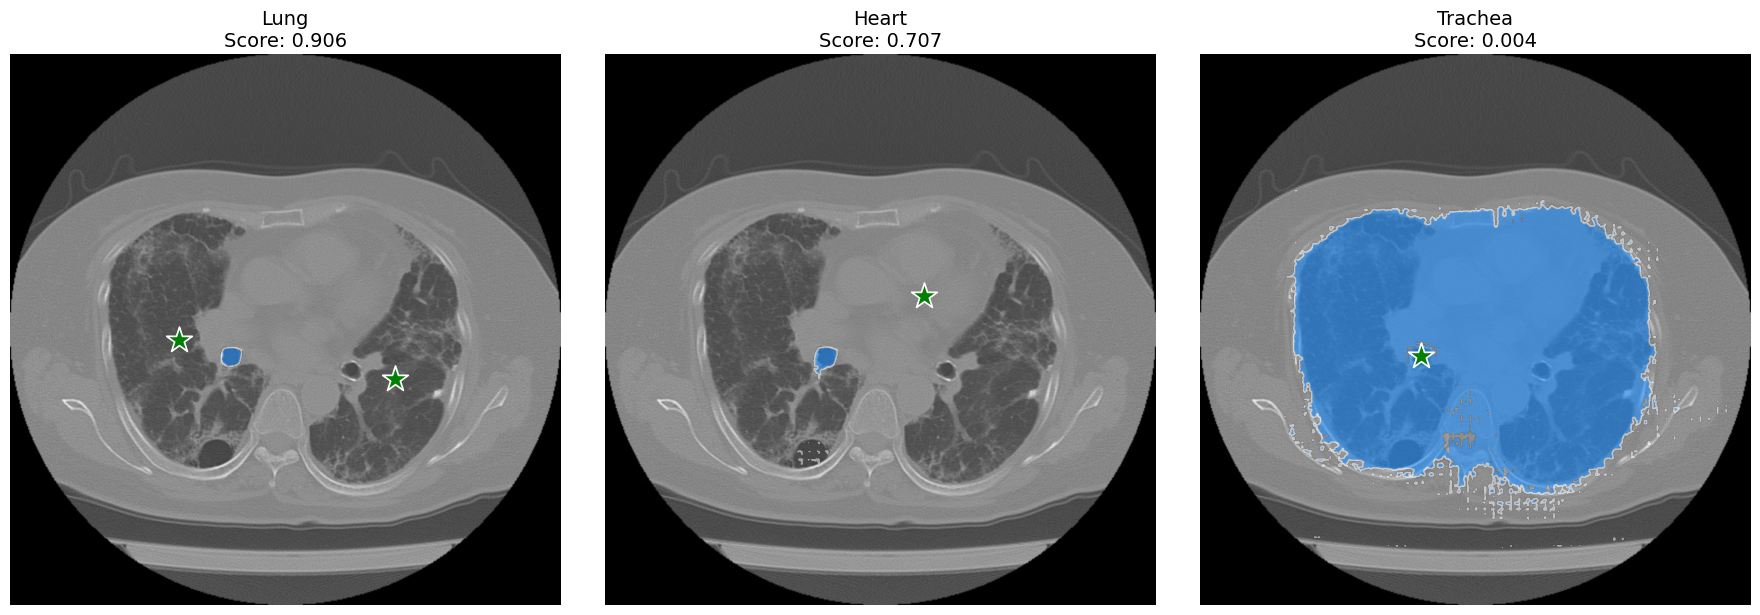

Step 1000: Train IoU = 0.3842, Val IoU = 0.5910
Checkpoint salvo: custom_checkpoints/model_dice_step_1000.torch


KeyboardInterrupt: 

In [29]:
# Recarrega modelo base
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)
predictor_dice = SAM2ImagePredictor(sam2_model)

# Configura treinamento apenas no mask decoder
predictor_dice.model.sam_mask_decoder.train(False)
predictor_dice.model.sam_prompt_encoder.train(False)
predictor_dice.model.image_encoder.train(True)

optimizer_dice = torch.optim.AdamW(params=predictor_dice.model.parameters(), lr=0.0001, weight_decay=1e-4)

# Mixed precision
scaler_dice = torch.amp.GradScaler("cuda")

# Treina modelo com Dice Loss
predictor_dice = train_model(
    predictor=predictor_dice,
    optimizer=optimizer_dice,
    scaler=scaler_dice,
    train_data=train_data,
    val_data=val_data,
    seg_loss_fn=dice_loss,
    model_name="model_dice",
    num_steps=3000,
    checkpoint_interval=500,
    val_interval=100
)


## Modelo 3: Dice + BCE Loss


In [30]:
# Recarrega modelo base
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)
predictor_dice_bce = SAM2ImagePredictor(sam2_model)

# Configura treinamento apenas no mask decoder
predictor_dice_bce.model.sam_mask_decoder.train(False)
predictor_dice_bce.model.sam_prompt_encoder.train(False)
predictor_dice_bce.model.image_encoder.train(True)

optimizer_dice_bce = torch.optim.AdamW(params=predictor_dice_bce.model.parameters(), lr=0.0001, weight_decay=1e-4)

# Mixed precision
scaler_dice_bce = torch.amp.GradScaler("cuda")

# Treina modelo com Dice + BCE Loss
predictor_dice_bce = train_model(
    predictor=predictor_dice_bce,
    optimizer=optimizer_dice_bce,
    scaler=scaler_dice_bce,
    train_data=train_data,
    val_data=val_data,
    seg_loss_fn=dice_bce_loss,
    model_name="model_dice_bce",
    num_steps=3000,
    checkpoint_interval=500,
    val_interval=100
)



Iniciando treinamento: model_dice_bce
Loss function: dice_bce_loss
Steps: 3000



OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB. GPU 0 has a total capacity of 3.81 GiB of which 24.69 MiB is free. Including non-PyTorch memory, this process has 3.78 GiB memory in use. Of the allocated memory 3.41 GiB is allocated by PyTorch, and 302.90 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [23]:
# Carrega o checkpoint 1000 de cross entropy e dice, para rodar a próxima célula

# Para Cross Entropy
sam2_model_ce = build_sam2(model_cfg, sam2_checkpoint, device=device)
predictor_ce = SAM2ImagePredictor(sam2_model_ce)
checkpoint_ce = torch.load("custom_checkpoints/model_ce_step_1000.torch", map_location=device)

# Detecta a chave correta para o state_dict
if 'model_state_dict' in checkpoint_ce:
    predictor_ce.model.load_state_dict(checkpoint_ce['model_state_dict'])
elif 'state_dict' in checkpoint_ce:
    predictor_ce.model.load_state_dict(checkpoint_ce['state_dict'])
else:
    # Tenta carregar diretamente, se o checkpoint for só o state_dict
    predictor_ce.model.load_state_dict(checkpoint_ce)

# Para Dice
sam2_model_dice = build_sam2(model_cfg, sam2_checkpoint, device=device)
predictor_dice = SAM2ImagePredictor(sam2_model_dice)
checkpoint_dice = torch.load("custom_checkpoints/model_dice_step_1000.torch", map_location=device)

if 'model_state_dict' in checkpoint_dice:
    predictor_dice.model.load_state_dict(checkpoint_dice['model_state_dict'])
elif 'state_dict' in checkpoint_dice:
    predictor_dice.model.load_state_dict(checkpoint_dice['state_dict'])
else:
    predictor_dice.model.load_state_dict(checkpoint_dice)

## Comparação dos Modelos


In [25]:
# Compara resultados dos 3 modelos
print("\n" + "="*60)
print("COMPARAÇÃO DOS MODELOS NA VALIDAÇÃO")
print("="*60)

# Avalia cada modelo na validação
print("\nAvaliando Cross Entropy Loss...")
results_ce = evaluate_on_validation(predictor_ce, val_data, verbose=False)
iou_ce = results_ce['overall_mean_iou']
print(f"Cross Entropy Loss:")
print(f"  IoU final na validação: {iou_ce:.4f}")

print("\nAvaliando Dice Loss...")
results_dice = evaluate_on_validation(predictor_dice, val_data, verbose=False)
iou_dice = results_dice['overall_mean_iou']
print(f"Dice Loss:")
print(f"  IoU final na validação: {iou_dice:.4f}")

# print("\nAvaliando Dice + BCE Loss...")
# results_dice_bce = evaluate_on_validation(predictor_dice_bce, val_data, verbose=False)
# iou_dice_bce = results_dice_bce['overall_mean_iou']
# print(f"Dice + BCE Loss:")
# print(f"  IoU final na validação: {iou_dice_bce:.4f}")

print("\n" + "="*60)

# Determina o melhor modelo
results = [
    ("Cross Entropy", iou_ce),
    ("Dice", iou_dice),
    # ("Dice + BCE", iou_dice_bce)
]

best_model = max(results, key=lambda x: x[1])
print(f"\nMelhor modelo: {best_model[0]} com IoU = {best_model[1]:.4f}")
print("="*60 + "\n")



COMPARAÇÃO DOS MODELOS NA VALIDAÇÃO

Avaliando Cross Entropy Loss...
Cross Entropy Loss:
  IoU final na validação: 0.0874

Avaliando Dice Loss...
Dice Loss:
  IoU final na validação: 0.2504


Melhor modelo: Dice com IoU = 0.2504

